<a href="https://colab.research.google.com/github/kevanugrah/Portofolio-Kevin-Anugrah/blob/main/CodeThesis_KevinAnugrah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Code Final Kevin Anugrah - 120450043**

*Import Library*

In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from tqdm import tqdm
from tabulate import tabulate
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_val_score,
    cross_val_predict,
    cross_validate
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


*Read Data Excel*


In [ ]:
df = pd.read_excel('/content/Data Final Fix KevinAnugrah.xlsx')

**Kita cek apakah terdapat data yang kosong / NULL**

In [ ]:
df.isnull().sum()

,0
Kategori,0
Komentar,0
Tanggal Posting,0
Nama Akun,0


*Kita lihat kolom ulasan yang akan kita gunakan sebagai fitur* **X**

In [ ]:
komentar=df['Komentar']
komentar

,Komentar
0,Gamble Strike 2
1,this game will take away your communication wi...
2,screaming russians is good ))
3,After play for 1300 hours i am still silver 2 ...
4,good
...,...
1127,Stupid
1128,games loved
1129,"bad game, the developer never listened to you"
1130,"Not lie, love this game"


***Kemudian kita lihat kolom kategori sebagai fitur*** **y**

In [ ]:
kategori=df['Kategori']
kategori

,Kategori
0,Direkomendasikan
1,Direkomendasikan
2,Direkomendasikan
3,Direkomendasikan
4,Direkomendasikan
...,...
1127,Tidak Direkomendasikan
1128,Direkomendasikan
1129,Tidak Direkomendasikan
1130,Direkomendasikan


In [ ]:
encoder = LabelEncoder()
df['kategori_encoding'] = encoder.fit_transform(df['Kategori'])

**Setelah kita berhasil membaca data, selanjutnya kita akan masuk ke**

**Pre-processing** Meliputi:  

1.   *Lowercasing*
2.   *Data Cleansing*
3.   *Tokenization*
4.   *Stop Word Removal*
5.   *Lemmatization*



In [ ]:
print("Kolom dalam data:", df.columns)

Kolom dalam data: Index(['Kategori', 'Komentar', 'Tanggal Posting', 'Nama Akun',
       'kategori_encoding'],
      dtype='object')


Data yang di pra-proses adalah data ulasan pelanggan

#**Pre-Processing**

In [ ]:
YELLOW = '\033[93m'
ENDC = '\033[0m'

##***Lowercasing***
*Membuat data ulasan teks menjadi huruf kecil, sehingga membuat bentuk teks seragam.*

In [ ]:
df['Lowercasing'] = df['Komentar'].str.lower()

In [ ]:
print(YELLOW + tabulate(df[['Komentar', 'Lowercasing']].head(5), headers='keys', tablefmt='fancy_grid'))
print(YELLOW + tabulate(df[['Komentar', 'Lowercasing']].tail(5), headers='keys', tablefmt='fancy_grid'))

╒════╤═══════════════════════════════════════════════════════════════╤═══════════════════════════════════════════════════════════════╕
│    │ Komentar                                                      │ Lowercasing                                                   │
╞════╪═══════════════════════════════════════════════════════════════╪═══════════════════════════════════════════════════════════════╡
│  0 │ Gamble Strike 2                                               │ gamble strike 2                                               │
├────┼───────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────┤
│  1 │ this game will take away your communication with your parents │ this game will take away your communication with your parents │
├────┼───────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────┤
│  2 │ screaming russians is good ))                   

##***Clean Text***
*Clean Text Dilakukan untuk membersihkan ulasan dari simbol, emoji, atau tanda baca yang tidak berpengaruh didalam model.*

In [ ]:
import re

df['Clean Text'] = df['Lowercasing'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

In [ ]:
print(YELLOW + tabulate(df[['Lowercasing','Clean Text']].head(5), headers='keys', tablefmt='fancy_grid'))
print(YELLOW + tabulate(df[['Lowercasing','Clean Text']].tail(5), headers='keys', tablefmt='fancy_grid'))

╒════╤═══════════════════════════════════════════════════════════════╤═══════════════════════════════════════════════════════════════╕
│    │ Lowercasing                                                   │ Clean Text                                                    │
╞════╪═══════════════════════════════════════════════════════════════╪═══════════════════════════════════════════════════════════════╡
│  0 │ gamble strike 2                                               │ gamble strike                                                 │
├────┼───────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────┤
│  1 │ this game will take away your communication with your parents │ this game will take away your communication with your parents │
├────┼───────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────┤
│  2 │ screaming russians is good ))                   

##***Tokenization***
*Disini Tokenization Dilakukan Untuk Memecah Kalimat menjadi Bentuk Token, agar dapat diproses dalam stopword removal.*

In [ ]:
!pip install nltk
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize


df['Tokenization'] = df['Clean Text'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
print(YELLOW + tabulate(df[['Clean Text','Tokenization']].head(5), headers='keys', tablefmt='fancy_grid'))
print(YELLOW + tabulate(df[['Clean Text','Tokenization']].tail(5), headers='keys', tablefmt='fancy_grid'))

╒════╤═══════════════════════════════════════════════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════╕
│    │ Clean Text                                                    │ Tokenization                                                                                 │
╞════╪═══════════════════════════════════════════════════════════════╪══════════════════════════════════════════════════════════════════════════════════════════════╡
│  0 │ gamble strike                                                 │ ['gamble', 'strike']                                                                         │
├────┼───────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────┤
│  1 │ this game will take away your communication with your parents │ ['this', 'game', 'will', 'take', 'away', 'your', 'communication', 'with', 'your', 'parents'] │
├───

##*Stopword Removal*

Melakukan stopword disini untuk menghapus kata hubung atau kata yang memiliki makna berulang

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


df['Stopword Removal'] = df['Tokenization'].apply(lambda tokens: [word for word in tokens if word not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print(YELLOW + tabulate(df[['Tokenization','Stopword Removal']].head(5), headers='keys', tablefmt='fancy_grid'))
print(YELLOW + tabulate(df[['Tokenization','Stopword Removal']].tail(5), headers='keys', tablefmt='fancy_grid'))

╒════╤══════════════════════════════════════════════════════════════════════════════════════════════╤══════════════════════════════════════════════════════╕
│    │ Tokenization                                                                                 │ Stopword Removal                                     │
╞════╪══════════════════════════════════════════════════════════════════════════════════════════════╪══════════════════════════════════════════════════════╡
│  0 │ ['gamble', 'strike']                                                                         │ ['gamble', 'strike']                                 │
├────┼──────────────────────────────────────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────────┤
│  1 │ ['this', 'game', 'will', 'take', 'away', 'your', 'communication', 'with', 'your', 'parents'] │ ['game', 'take', 'away', 'communication', 'parents'] │
├────┼────────────────────────────────────────────────────

##*Lemmatization*

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
from nltk import pos_tag

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
from nltk import pos_tag

nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet


lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def lemmatize_tokens(tokens):
    pos_tags = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]


df['Lemmatization'] = df['Stopword Removal'].apply(lemmatize_tokens)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
from tabulate import tabulate


print(YELLOW +  tabulate(df[['Stopword Removal', 'Lemmatization']].head(5), headers='keys', tablefmt='fancy_grid'))
print(YELLOW +  tabulate(df[['Stopword Removal', 'Lemmatization']].tail(5), headers='keys', tablefmt='fancy_grid'))

╒════╤══════════════════════════════════════════════════════╤═════════════════════════════════════════════════════╕
│    │ Stopword Removal                                     │ Lemmatization                                       │
╞════╪══════════════════════════════════════════════════════╪═════════════════════════════════════════════════════╡
│  0 │ ['gamble', 'strike']                                 │ ['gamble', 'strike']                                │
├────┼──────────────────────────────────────────────────────┼─────────────────────────────────────────────────────┤
│  1 │ ['game', 'take', 'away', 'communication', 'parents'] │ ['game', 'take', 'away', 'communication', 'parent'] │
├────┼──────────────────────────────────────────────────────┼─────────────────────────────────────────────────────┤
│  2 │ ['screaming', 'russians', 'good']                    │ ['scream', 'russian', 'good']                       │
├────┼──────────────────────────────────────────────────────┼───────────

##Distribusi Data

Disini Kita Cek Distribusi Datanya agar diketahui apakah data yang kita gunakan seimbang atau tidak

In [ ]:
print("\n=== Distribusi Kelas ===")
distribusi = df['Kategori'].value_counts()
print(distribusi)


=== Distribusi Kelas ===
Kategori
Direkomendasikan          734
Tidak Direkomendasikan    398
Name: count, dtype: int64


**Visualisasi Distribusi Data**

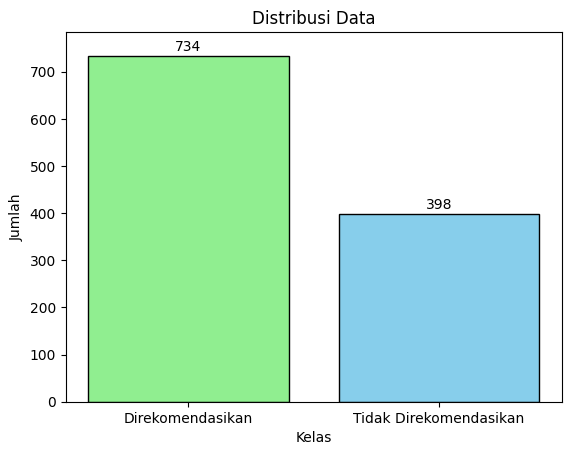

In [ ]:


plt.bar(distribusi.index, distribusi.values, color=['lightgreen', 'skyblue'], edgecolor='black')


for i, count in enumerate(distribusi.values):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.title('Distribusi Data')
plt.ylim(0, max(distribusi.values) + 50)  # batas atas +50
plt.show()

#**Split Data 80:20**
*Data di bagi dengan proporsi 80% untuk data Training dan 20% untuk data Testing.*

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['Lemmatization'], df['kategori_encoding'],
                                                    stratify= df['kategori_encoding'], test_size=0.2, random_state=42)

In [ ]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (905,)
Shape of X_test: (227,)
Shape of y_train: (905,)
Shape of y_test: (227,)


In [ ]:
original_counts = df['kategori_encoding'].value_counts().sort_index()
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

original_proportions = original_counts / original_counts.sum()
train_proportions = train_counts / train_counts.sum()
test_proportions = test_counts / test_counts.sum()

distribution_df = pd.DataFrame({
    'kategori encode': original_counts.index,
    'Jumlah Data Original': original_counts.values,
    'Jumlah Data Latih': train_counts.values,
    'Jumlah Data Uji': test_counts.values,
})
print(distribution_df)

   kategori encode  Jumlah Data Original  Jumlah Data Latih  Jumlah Data Uji
0                0                   734                587              147
1                1                   398                318               80


##TF-IDF Data Latih


In [ ]:

X_train_text = X_train
X_test_text = X_test


if isinstance(X_train_text[0], list):
    X_train_text = [' '.join(tokens) for tokens in X_train_text]
    X_test_text = [' '.join(tokens) for tokens in X_test_text]


from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_final = TfidfVectorizer()
X_train_tfidf_final = tfidf_final.fit_transform(X_train_text)
X_test_tfidf_final = tfidf_final.transform(X_test_text)


In [ ]:
if isinstance(X_train[0], list):
    X_train = [' '.join(tokens) for tokens in X_train]
    X_test_text = [' '.join(tokens) for tokens in X_test_text]

In [ ]:
import pandas as pd

tfidf_matrix = pd.DataFrame(
    X_train_tfidf_final.toarray(),
    columns=tfidf_final.get_feature_names_out()
)

tfidf_preview = pd.concat([tfidf_matrix.head(5), tfidf_matrix.tail(5)])

TF-IDF Data Latih

In [ ]:
from tabulate import tabulate

# Tampilkan sebagai tabel ASCII
print("=== Matriks TF-IDF Data Latih ===")
print(YELLOW + tabulate(tfidf_preview, headers='keys', tablefmt='fancy_grid'))


=== Matriks TF-IDF Data Latih ===
╒═════╤════════╤════════════╤══════════════╤═══════╤═══════════╤══════════╤═══════╤══════════╤═════════════╤═════════════╤═════════╤═══════╤═══════╤═════════╤════════╤═══════════╤════════╤══════════╤═════════╤═══════════╤═══════════╤══════════╤═════════╤════════╤═════════════╤═══════════╤══════════╤════════════╤══════════╤══════╤═══════╤═══════════╤══════════╤═════════════╤═════════╤═══════════╤═════════╤═════════╤═══════════╤════════╤════════╤═══════╤═══════════╤════════╤═══════╤════════╤══════════╤════════╤═════════════╤══════════╤═══════════╤═════════╤════════╤═══════╤═══════╤═════════╤═════════╤════════╤════════╤═══════════╤════════╤════════╤══════════╤═══════╤════════╤═════════╤═══════╤══════════╤═══════════╤═════════╤═══════╤════════════╤════════════╤══════════╤═══════╤════════╤════════╤══════════╤═════════════╤═════════╤═══════════╤══════════════╤═══════════╤═════════╤═════════════╤═════════╤═══════════╤══════════╤══════════╤═══════════╤════════

TF-IDF Data Uji

In [ ]:

tfidf_test_df = pd.DataFrame(X_test_tfidf_final.toarray(), columns=tfidf_final.get_feature_names_out())


tfidf_test_preview = pd.concat([tfidf_test_df.head(5), tfidf_test_df.tail(5)])


print("\n=== Matriks TF-IDF Data Uji ===")
print(YELLOW + tabulate(tfidf_test_preview, headers='keys', tablefmt='fancy_grid', floatfmt=".3f"))



=== Matriks TF-IDF Data Uji ===
╒═════╤════════╤════════════╤══════════════╤═══════╤═══════════╤══════════╤═══════╤══════════╤═════════════╤═════════════╤═════════╤═══════╤═══════╤═════════╤════════╤═══════════╤════════╤══════════╤═════════╤═══════════╤═══════════╤══════════╤═════════╤════════╤═════════════╤═══════════╤══════════╤════════════╤════════╤═══════╤═══════╤═══════════╤══════════╤═════════════╤═════════╤═══════════╤═════════╤═════════╤═══════════╤════════╤════════╤═══════╤═══════════╤════════╤═══════╤════════╤══════════╤════════╤═════════════╤══════════╤═══════════╤════════╤════════╤═══════╤═══════╤═════════╤═════════╤════════╤════════╤═══════════╤════════╤════════╤══════════╤═══════╤════════╤═════════╤═══════╤══════════╤═══════════╤═════════╤═══════╤════════════╤════════════╤══════════╤═══════╤════════╤════════╤══════════╤═════════════╤═════════╤═══════════╤══════════════╤═══════════╤═════════╤═════════════╤═════════╤═══════════╤══════════╤══════════╤═══════════╤═════════╤═

#**SMOTE**

###**Cek Distribusi Kelas Pada Data Train**

Label Positif: 587
Label Negatif: 318


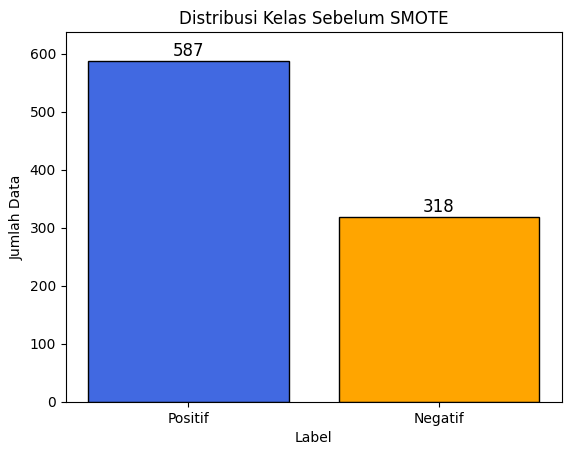

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


unique, counts = np.unique(y_train, return_counts=True)

label_mapping = {0: 'Positif', 1: 'Negatif'}
labels_text = [label_mapping[l] for l in unique]

for label, count in zip(labels_text, counts):
    print(f"Label {label}: {count}")


plt.bar(labels_text, counts, color=['royalblue', 'orange'], edgecolor='black')

for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12)
plt.ylim(0, max(counts) + 50)
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Kelas Sebelum SMOTE')
plt.show()


Hasil dari pengecekan pada data train, didapatkan bahwa terdapat ketidakseimbangan kelas (Imbalance Class) maka dari itu kita lakukan SMOTE untuk menyeimbangkan kelas pada data

Label Positif setelah SMOTE: 587
Label Negatif setelah SMOTE: 587


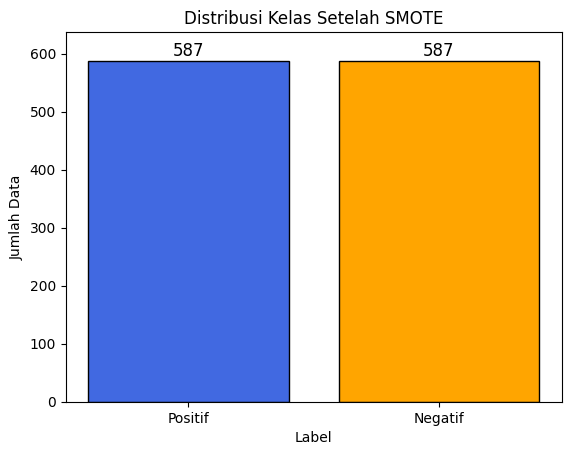

In [ ]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf_final, y_train)


unique_smote, counts_smote = np.unique(y_train_smote, return_counts=True)


labels_smote_text = [label_mapping[l] for l in unique_smote]


for label, count in zip(labels_smote_text, counts_smote):
    print(f"Label {label} setelah SMOTE: {count}")


plt.bar(labels_smote_text, counts_smote, color=['royalblue', 'orange'], edgecolor='black')


for i, count in enumerate(counts_smote):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12)
plt.ylim(0, max(counts) + 50)
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Kelas Setelah SMOTE')
plt.show()


 ## **Pencarian Hyperparameter Terbaik (Nilai K)**

**Pada tahap ini data train dimasukan kedalam sebuah pipeline yang bertujuan untuk mencari nilai K tetangga paling baik dari 10 Nilai yang diuji**

In [ ]:
# ==============================
# PIPELINE DAN GRID SEARCH
# ==============================
PipelineModel = Pipeline([
    ('tfidf', TfidfVectorizer(norm=None)),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(metric='cosine'))
])

ParameterGrid = {
    'knn__n_neighbors': range(1, 11),
    'knn__weights': ['uniform', 'distance']
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

GridSearch = GridSearchCV(
    PipelineModel,
    ParameterGrid,
    cv=kf,
    scoring='accuracy',
    n_jobs=1,
    verbose=2,
    error_score='raise'
)

GridSearch.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ...........knn__n_neighbors=1, knn__weights=uniform; total time=   0.0s
[CV] END ...........knn__n_neighbors=1, knn__weights=uniform; total time=   0.0s
[CV] END ...........knn__n_neighbors=1, knn__weights=uniform; total time=   0.0s
[CV] END ...........knn__n_neighbors=1, knn__weights=uniform; total time=   0.0s
[CV] END ...........knn__n_neighbors=1, knn__weights=uniform; total time=   0.0s
[CV] END ..........knn__n_neighbors=1, knn__weights=distance; total time=   0.0s
[CV] END ..........knn__n_neighbors=1, knn__weights=distance; total time=   0.0s
[CV] END ..........knn__n_neighbors=1, knn__weights=distance; total time=   0.0s
[CV] END ..........knn__n_neighbors=1, knn__weights=distance; total time=   0.0s
[CV] END ..........knn__n_neighbors=1, knn__weights=distance; total time=   0.0s
[CV] END ...........knn__n_neighbors=2, knn__weights=uniform; total time=   0.0s
[CV] END ...........knn__n_neighbors=2, knn__we

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer(norm=None)),
                                       ('smote', SMOTE(random_state=42)),
                                       ('knn',
                                        KNeighborsClassifier(metric='cosine'))]),
             n_jobs=1,
             param_grid={'knn__n_neighbors': range(1, 11),
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [ ]:
MAGENTA = '\033[95m'
CYAN = '\033[96m'
YELLOW = '\033[93m'
GREEN = '\033[92m'
RESET = '\033[0m'
BOLD = '\033[1m'

X_train_array = np.array(X_train)
y_train_array = np.array(y_train)

# Mapping label
label_map = {0: 'positif', 1: 'negatif'}

smote = SMOTE(random_state=42)



for k in range(1, 11):
    print(f"{BOLD}{MAGENTA}=== Pembagian Fold untuk k = {k} ==={RESET}\n")
    fold = 1

    for train_idx, val_idx in kf.split(X_train_array):

        X_fold_train = X_train_array[train_idx]
        y_fold_train = y_train_array[train_idx]
        X_fold_val = X_train_array[val_idx]


        tfidf = TfidfVectorizer(norm=None)
        X_fold_train_tfidf = tfidf.fit_transform(X_fold_train)
        X_fold_val_tfidf = tfidf.transform(X_fold_val)


        unique_before, counts_before = np.unique(y_fold_train, return_counts=True)
        distribusi_before = {label_map[label]: count for label, count in zip(unique_before, counts_before)}


        X_res, y_res = smote.fit_resample(X_fold_train_tfidf, y_fold_train)


        unique_after, counts_after = np.unique(y_res, return_counts=True)
        distribusi_after = {label_map[label]: count for label, count in zip(unique_after, counts_after)}


        print(f"{CYAN}{BOLD}Fold {fold}:{RESET}")
        print(f"  {YELLOW}Jumlah data latih sebelum SMOTE{RESET} : {len(train_idx)}")
        print(f"    {GREEN}Distribusi: {distribusi_before}{RESET}")
        print(f"  {YELLOW}Jumlah data validasi{RESET}            : {len(val_idx)}")
        print(f"  {YELLOW}Jumlah data latih setelah SMOTE{RESET} : {len(y_res)}")
        print(f"    {GREEN}Distribusi: {distribusi_after}{RESET}")
        print(f"  {'-'*60}")
        fold += 1


=== Pembagian Fold untuk k = 1 ===

Fold 1:
  Jumlah data latih sebelum SMOTE : 724
    Distribusi: {'positif': np.int64(478), 'negatif': np.int64(246)}
  Jumlah data validasi            : 181
  Jumlah data latih setelah SMOTE : 956
    Distribusi: {'positif': np.int64(478), 'negatif': np.int64(478)}
  ------------------------------------------------------------
Fold 2:
  Jumlah data latih sebelum SMOTE : 724
    Distribusi: {'positif': np.int64(467), 'negatif': np.int64(257)}
  Jumlah data validasi            : 181
  Jumlah data latih setelah SMOTE : 934
    Distribusi: {'positif': np.int64(467), 'negatif': np.int64(467)}
  ------------------------------------------------------------
Fold 3:
  Jumlah data latih sebelum SMOTE : 724
    Distribusi: {'positif': np.int64(474), 'negatif': np.int64(250)}
  Jumlah data validasi            : 181
  Jumlah data latih setelah SMOTE : 948
    Distribusi: {'positif': np.int64(474), 'negatif': np.int64(474)}
  --------------------------------------

Pembagian tiap fold

In [ ]:
ParameterTerbaik = GridSearch.best_params_
KTerbaik = ParameterTerbaik['knn__n_neighbors']
BobotTerbaik = ParameterTerbaik['knn__weights']

In [ ]:
print("Parameter terbaik:", ParameterTerbaik)
print("K terbaik:", KTerbaik)
print("Weights terbaik:", BobotTerbaik)
print("Akurasi terbaik:", GridSearch.best_score_)

Parameter terbaik: {'knn__n_neighbors': 5, 'knn__weights': 'distance'}
K terbaik: 5
Weights terbaik: distance
Akurasi terbaik: 0.8983425414364641


In [ ]:
AverageSkorCV = GridSearch.cv_results_['mean_test_score']
params = GridSearch.cv_results_['params']

In [ ]:
data = [(p['knn__n_neighbors'], p['knn__weights'], s) for p, s in zip(params, AverageSkorCV)]
df = pd.DataFrame(data, columns=['k', 'weights', 'score'])

In [ ]:
df_uniform = df[df['weights'] == 'uniform'].sort_values(by='k')
df_distance = df[df['weights'] == 'distance'].sort_values(by='k')

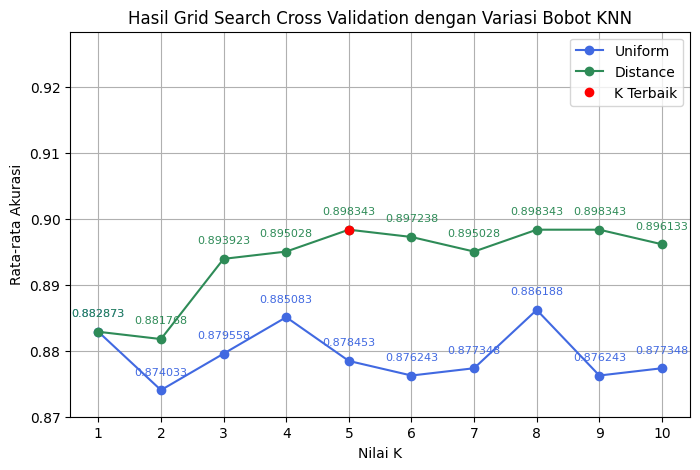

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_uniform['k'], df_uniform['score'], marker='o', label='Uniform', color='royalblue')
plt.plot(df_distance['k'], df_distance['score'], marker='o', label='Distance', color='seagreen')


for x, y in zip(df_uniform['k'], df_uniform['score']):
    plt.text(x, y + 0.002, f"{y:.6f}", ha='center', va='bottom', fontsize=8, color='royalblue')

for x, y in zip(df_distance['k'], df_distance['score']):
    plt.text(x, y + 0.002, f"{y:.6f}", ha='center', va='bottom', fontsize=8, color='seagreen')


best_row = df.loc[df['score'].idxmax()]
plt.plot(best_row['k'], best_row['score'], 'ro', label='K Terbaik')


y_max = df['score'].max()
plt.ylim(0.87, y_max + 0.03)

# Format plot
plt.title("Hasil Grid Search Cross Validation dengan Variasi Bobot KNN")
plt.xlabel("Nilai K")
plt.ylabel("Rata-rata Akurasi")
plt.xticks(df['k'].unique())
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("Hasil Grid Search (Uniform):")
for k, score in zip(df_uniform['k'], df_uniform['score']):
    print(f"K = {k:2d} | Akurasi = {score:.10f}")

print("\nHasil Grid Search (Distance):")
for k, score in zip(df_distance['k'], df_distance['score']):
    print(f"K = {k:2d} | Akurasi = {score:.10f}")


Hasil Grid Search (Uniform):
K =  1 | Akurasi = 0.8828729282
K =  2 | Akurasi = 0.8740331492
K =  3 | Akurasi = 0.8795580110
K =  4 | Akurasi = 0.8850828729
K =  5 | Akurasi = 0.8784530387
K =  6 | Akurasi = 0.8762430939
K =  7 | Akurasi = 0.8773480663
K =  8 | Akurasi = 0.8861878453
K =  9 | Akurasi = 0.8762430939
K = 10 | Akurasi = 0.8773480663

Hasil Grid Search (Distance):
K =  1 | Akurasi = 0.8828729282
K =  2 | Akurasi = 0.8817679558
K =  3 | Akurasi = 0.8939226519
K =  4 | Akurasi = 0.8950276243
K =  5 | Akurasi = 0.8983425414
K =  6 | Akurasi = 0.8972375691
K =  7 | Akurasi = 0.8950276243
K =  8 | Akurasi = 0.8983425414
K =  9 | Akurasi = 0.8983425414
K = 10 | Akurasi = 0.8961325967


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_final = KNeighborsClassifier(
    n_neighbors=KTerbaik,
    weights=BobotTerbaik,
    metric='cosine'
)
model_final.fit(X_train_smote, y_train_smote)


KNeighborsClassifier(metric='cosine', weights='distance')

didapatkan bahwa hasil grid search yang tebaik adalah menggunakan tetangga 5 dengan pembobotan distance

In [ ]:
ParameterTerbaik

{'knn__n_neighbors': 5, 'knn__weights': 'distance'}

Prediksi Data Latih

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Prediksi data latih (hasil SMOTE)
y_train_pred = model_final.predict(X_train_smote)

print("=== Evaluasi Data Latih ===")
print(f"Metric yang digunakan   : {model_final.metric}")
print(f"Nilai K yang digunakan  : {model_final.n_neighbors}")
print(f"Weights yang digunakan  : {model_final.weights}")
print("-" * 40)
print("Akurasi    :", accuracy_score(y_train_smote, y_train_pred))
print("Presisi  Direkomendasikan  :", precision_score(y_train_smote, y_train_pred, pos_label=1))
print("Recall    Direkomendasikan :", recall_score(y_train_smote, y_train_pred, pos_label=1))
print("F1-Score Direkomendasikan  :", f1_score(y_train_smote, y_train_pred, pos_label=1))
print("Presisi   Tidak Direkomendasikan :", precision_score(y_train_smote, y_train_pred, pos_label=0))
print("Recall   Tidak Direkomendasikan  :", recall_score(y_train_smote, y_train_pred, pos_label=0))
print("F1-Score Tidak Direkomendasikan  :", f1_score(y_train_smote, y_train_pred, pos_label=0))
print("Confusion Matrix:\n", confusion_matrix(y_train_smote, y_train_pred))


=== Evaluasi Data Latih ===
Metric yang digunakan   : cosine
Nilai K yang digunakan  : 5
Weights yang digunakan  : distance
----------------------------------------
Akurasi    : 0.9889267461669506
Presisi  Direkomendasikan  : 0.9897610921501706
Recall    Direkomendasikan : 0.9880749574105622
F1-Score Direkomendasikan  : 0.9889173060528559
Presisi   Tidak Direkomendasikan : 0.9880952380952381
Recall   Tidak Direkomendasikan  : 0.989778534923339
F1-Score Tidak Direkomendasikan  : 0.9889361702127659
Confusion Matrix:
 [[581   6]
 [  7 580]]


Perhitungan Jarak antar Data Train

In [ ]:
from sklearn.metrics import pairwise_distances
import pandas as pd

# Hitung jarak antar data latih (SMOTE)
distances = pairwise_distances(X_train_smote, metric=model_final.metric)

# Tampilkan sebagian hasil (karena matriks jarak akan sangat besar jika datanya banyak)
distances_df = pd.DataFrame(distances)
print("=== Contoh Jarak Antar Data Latih ===")
print(distances_df.head())  # hanya menampilkan 5 baris pertama
print(distances_df.tail())  # hanya menampilkan 5 baris terakhir



=== Contoh Jarak Antar Data Latih ===
   0     1     2         3         4         5         6         7     8     \
0   0.0   1.0   1.0  1.000000  1.000000  1.000000  1.000000  0.970971   1.0   
1   1.0   0.0   1.0  1.000000  1.000000  1.000000  1.000000  1.000000   1.0   
2   1.0   1.0   0.0  1.000000  1.000000  1.000000  1.000000  1.000000   1.0   
3   1.0   1.0   1.0  0.000000  0.842618  0.656863  0.849448  1.000000   1.0   
4   1.0   1.0   1.0  0.842618  0.000000  0.541344  0.798763  1.000000   1.0   

       9     ...      1164      1165     1166  1167      1168  1169      1170  \
0  0.925074  ...  0.982225  0.988077  1.00000   1.0  0.982502   1.0  0.975935   
1  1.000000  ...  1.000000  0.831382  0.85967   1.0  1.000000   1.0  1.000000   
2  1.000000  ...  1.000000  1.000000  1.00000   1.0  1.000000   1.0  1.000000   
3  0.716307  ...  1.000000  1.000000  1.00000   1.0  1.000000   1.0  1.000000   
4  0.620799  ...  1.000000  1.000000  1.00000   1.0  1.000000   1.0  1.000000   



##**Evaluasi Model Pada Data Uji**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#Melak
y_test_pred = model_final.predict(X_test_tfidf_final)

print("=== Evaluasi Data Uji ===")
print(f"Metric yang digunakan   : {model_final.metric}")
print(f"Nilai K yang digunakan  : {model_final.n_neighbors}")
print(f"Weights yang digunakan  : {model_final.weights}")
print("-" * 40)
print("Akurasi    :", accuracy_score(y_test, y_test_pred))
print("Presisi  Direkomendasikan  :", precision_score(y_test, y_test_pred, pos_label=0))
print("Recall   Direkomendasikan  :", recall_score(y_test, y_test_pred, pos_label=0))
print("F1-Score Direkomendasikan  :", f1_score(y_test, y_test_pred, pos_label=0))
print("Presisi  Tidak Direkomendasikan  :", precision_score(y_test, y_test_pred, pos_label=1))
print("Recall   Tidak Direkomendasikan  :", recall_score(y_test, y_test_pred, pos_label=1))
print("F1-Score Tidak Direkomendasikan  :", f1_score(y_test, y_test_pred, pos_label=1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))


=== Evaluasi Data Uji ===
Metric yang digunakan   : cosine
Nilai K yang digunakan  : 5
Weights yang digunakan  : distance
----------------------------------------
Akurasi    : 0.8942731277533039
Presisi  Direkomendasikan  : 0.9361702127659575
Recall   Direkomendasikan  : 0.8979591836734694
F1-Score Direkomendasikan  : 0.9166666666666666
Presisi  Tidak Direkomendasikan  : 0.8255813953488372
Recall   Tidak Direkomendasikan  : 0.8875
F1-Score Tidak Direkomendasikan  : 0.8554216867469879
Confusion Matrix:
 [[132  15]
 [  9  71]]


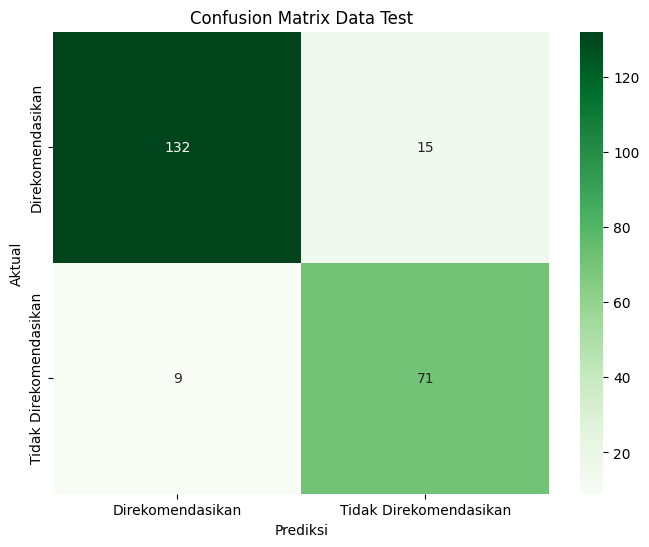

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Perhitungan CM
cm = confusion_matrix(y_test, y_test_pred)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Direkomendasikan', 'Tidak Direkomendasikan'],
            yticklabels=['Direkomendasikan', 'Tidak Direkomendasikan'])

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Data Test")
plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_distances
import pandas as pd
from tabulate import tabulate


jarak_uji_ke_latih = cosine_distances(X_test_tfidf_final.toarray(), X_train_smote.toarray())


df_jarak_uji_ke_latih = pd.DataFrame(jarak_uji_ke_latih)


top_rows = df_jarak_uji_ke_latih.head(3)
bottom_rows = df_jarak_uji_ke_latih.tail(3)


top_combined = pd.concat([top_rows.iloc[:, :3], top_rows.iloc[:, -3:]], axis=1)
bottom_combined = pd.concat([bottom_rows.iloc[:, :3], bottom_rows.iloc[:, -3:]], axis=1)

result_df = pd.concat([top_combined, bottom_combined])


print("\n=== Matriks Jarak Cosine Data Uji ke Data Latih ===")
print(tabulate(result_df.round(4), headers='keys', tablefmt='pretty'))



=== Matriks Jarak Cosine Data Uji ke Data Latih ===
+-----+--------+--------+-----+--------+------+--------+
|     |   0    |   1    |  2  |  1171  | 1172 |  1173  |
+-----+--------+--------+-----+--------+------+--------+
|  0  | 0.7243 |  1.0   | 1.0 |  1.0   | 1.0  |  1.0   |
|  1  | 0.9697 |  1.0   | 1.0 |  1.0   | 1.0  | 0.9795 |
|  2  | 0.9794 | 0.7091 | 1.0 | 0.7091 | 1.0  | 0.9861 |
| 224 |  1.0   |  1.0   | 1.0 |  1.0   | 1.0  |  1.0   |
| 225 |  1.0   |  1.0   | 1.0 |  1.0   | 1.0  |  1.0   |
| 226 |  1.0   |  1.0   | 1.0 |  1.0   | 1.0  |  1.0   |
+-----+--------+--------+-----+--------+------+--------+
